[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap01/cap01_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

<!-- cap 1 -->

# Representação de Imagens Digitais

Este capítulo inaugura a **Parte 1** do livro, focada nos fundamentos do Processamento Digital de Imagens. 
Aqui, você aprenderá como as imagens são representadas matematicamente e como manipulá-las 
usando Python e a biblioteca `morph.py` [@zampirolli2025morph].

## Objetivos

Ao final deste capítulo, você será capaz de:

- Compreender a natureza física e matemática da imagem digital $f(x,y)$.
- Identificar as faixas do espectro eletromagnético relevantes para PDI.
- Configurar o ambiente de desenvolvimento em Python.
- Realizar operações básicas: leitura, exibição e salvamento de imagens.
- Manipular estruturas de matrizes (NumPy) sem cair em armadilhas de memória.
- Acessar e modificar intensidades de pixels individualmente.
- Aplicar limiarização manual e automática (método de Otsu).

## Antes de começar: *Notebooks* em Python

Este material foi construído sob o conceito de ***Literate Programming*** (Programação Literária), idealizado por Donald Knuth na década de 84 [@knuth_literate_1984]. Knuth — também criador do sistema **TeX** para tipografia digital — propôs que os programas fossem escritos como uma narrativa lógica para seres humanos, intercalando código e documentação.

Para executar uma célula, pressione <kbd>Shift</kbd> + <kbd>Enter</kbd> ou clique no botão ▶️.

::: {.callout-note}
### Nota sobre o formato {.unnumbered}

Se você estiver lendo a versão renderizada (PDF ou HTML), o código aparecerá como blocos estáticos. Para interagir, acesse o link do **Google Colab** no topo da página.
:::

## Fundamentos

O estudo de sistemas baseados em imagens compreende um ecossistema de disciplinas integradas que transformam dados visuais brutos em conhecimento estruturado. Enquanto algumas áreas focam na geração de representações, outras dedicam-se ao tratamento e à análise desses dados para dar suporte a aplicações tecnológicas complexas.

O diagrama apresentado no @fig-1-representacao estabelece a distinção e complementaridade entre o Processamento de Imagens (PDI) e a Visão Computacional (VC). O PDI, destacado em **verde**, tem como foco a transformação de imagem para imagem, visando melhoria de qualidade ou pré-processamento, como a remoção de ruídos e realce de contraste.

Em contrapartida, a VC, assinalada em **azul**, foca na interpretação do conteúdo visual para extrair modelos ou informações, como o reconhecimento de objetos e gestos. A região de intersecção ilustra a sinergia entre as áreas, onde o PDI prepara os dados visuais para a interpretação pela VC. O mapa também demonstra as interconexões de ambas as disciplinas com áreas como Robótica, Computação Gráfica, Inteligência Artificial e Neurociência.

::: {#fig-1-representacao}

![](imagens/fig-1-pdf-vc.png){width=90% fig-align="center"}

Diagrama relacional detalhando as distinções fundamentais, sinergias e interconexões entre Processamento de Imagens e Visão Computacional no contexto de sistemas baseados em imagens.

:::

### 👁️ Visão Computacional

- **Foco:** *Imagem → Modelo* (caminho inverso da Computação Gráfica).  
- **Objetivo:** Extrair informação de alto nível a partir de imagens ou vídeos.  
- **Aplicações típicas:**
  - Robótica – detecção de obstáculos, localização e navegação autônoma.
  - Vigilância e inspeção – reconhecimento de eventos, leitura de placas, controle de qualidade.
  - Sensoriamento remoto – análise de imagens de satélite, mapeamento ambiental.
  - Imagens médicas – detecção de tumores, segmentação de órgãos, auxílio ao diagnóstico.
  - Interação humano‑computador – reconhecimento de gestos, expressões faciais, rastreamento ocular.
- **Relação com outras áreas:** utiliza técnicas de Aprendizado de Máquina e IA para classificar e interpretar cenas; serve como “olhos” da Robótica.

### 🖼️ Processamento de Imagens (PDI)

- **Foco:** *Imagem → Imagem* (geralmente – transformação de uma imagem em outra).  
- **Objetivo:** Melhorar a qualidade visual ou extrair características de baixo nível.  
- **Aplicações comuns:**
  - Eliminação de ruídos (filtros de média, mediana, gaussiano).
  - Melhoria de contraste (equalização de histograma, ajuste gamma).
  - Detecção de bordas (Sobel, Canny, Laplaciano).
  - Segmentação (limiarização, crescimento de regiões, watershed).
  - Transformações geométricas (redimensionamento, rotação, correção de perspectiva).
- **Relação com outras áreas:**  
  - É a **base** para a maioria dos sistemas de Visão Computacional (pré‑processamento).  
  - A Computação Gráfica frequentemente aplica PDI para pós‑processamento (ex.: suavização, realce).  
  - Técnicas de IA podem otimizar parâmetros de processamento (ex.: aprendizado de filtros).


###  Como as “Outras Áreas” se conectam

| Área                      | Relação com PDI e VC                                                                 |
|---------------------------|--------------------------------------------------------------------------------------|
| **Inteligência Artificial** | Fornece modelos (redes neurais, SVM) que interpretam saídas da VC.                    |
| **Robótica**              | Consome dados de VC para tomar decisões (navegação, manipulação).                     |
| **Aprendizado de Máquina**| Usa descritores extraídos pelo PDI/VC para treinar classificadores.                   |
| **Computação Gráfica**    | Caminho inverso: *modelo → imagem*; muitas vezes aplica PDI para renderização realista. |
| **Neurociência**          | Inspira modelos de PDI (ex.: filtros semelhantes a células ganglionares da retina).   |

## Formação da Imagem e o Espectro

O processo de formação de uma imagem é fundamentado na interação entre a matéria e a energia radiante. Essencialmente, uma imagem é concebida quando um **sensor registra a radiação** resultante da interação com um objeto físico. No contexto da visão humana e da fotografia convencional, este fenômeno depende de uma fonte de luz que ilumine a cena; as características dos objetos são então codificadas através das **variações de intensidade e cor** da luz que atinge o sensor, conforme ilustrado na @fig-1-luz.

::: {#fig-1-luz}

![](imagens/fig-1-luz.png){width=90% fig-align="center"}

Representação do espectro visível e sua posição em relação às demais radiações eletromagnéticas, destacando a variação dos comprimentos de onda de 380 nm a 750 nm.
:::

A **luz visível** ocupa apenas uma pequena faixa do espectro eletromagnético — entre **380 nm (violeta)** e **750 nm (vermelho)** —, conforme ilustrado na @fig-1-espectro. Sensores digitais convencionais operam nessa mesma janela, mas equipamentos especializados podem captar radiações invisíveis ao olho humano, como o infravermelho e os raios X. Em PDI, a imagem formada depende diretamente da sensibilidade espectral do sensor utilizado.

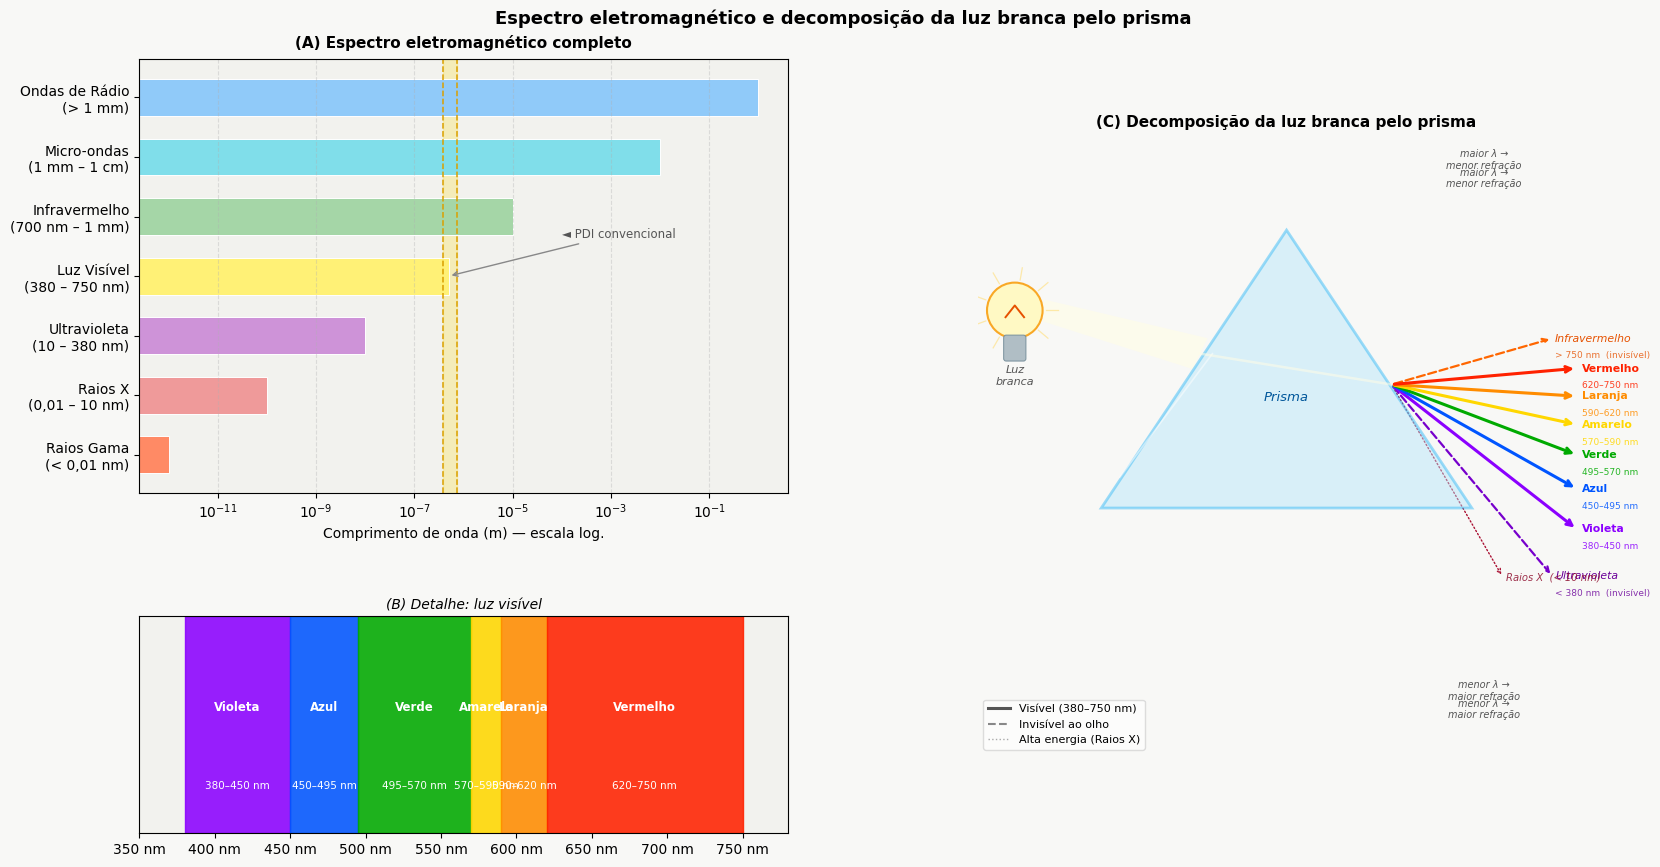

In [ ]:
#| label: fig-1-espectro
#| fig-cap: "(A) Espectro eletromagnético completo em escala logarítmica, com destaque para a faixa visível. (B) Detalhe da luz visível (380–750 nm) e suas cores componentes. (C) Decomposição da luz branca pelo prisma: menor comprimento de onda sofre maior refração, separando UV, visível e infravermelho."
#| echo: false
#| output: true
#| fig-width: 16
#| fig-height: 9

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon

# ═══════════════════════════════════════════════════════════════════
# Dados
# ═══════════════════════════════════════════════════════════════════
faixas = [
    'Ondas de Rádio\n(> 1 mm)',
    'Micro-ondas\n(1 mm – 1 cm)',
    'Infravermelho\n(700 nm – 1 mm)',
    'Luz Visível\n(380 – 750 nm)',
    'Ultravioleta\n(10 – 380 nm)',
    'Raios X\n(0,01 – 10 nm)',
    'Raios Gama\n(< 0,01 nm)',
]
comprimentos_rep = [1e0, 1e-2, 1e-5, 5e-7, 1e-8, 1e-10, 1e-12]
cores_barras     = ['#90CAF9', '#80DEEA', '#A5D6A7', '#FFF176',
                    '#CE93D8', '#EF9A9A', '#FF8A65']

limites_nm = [380, 450, 495, 570, 590, 620, 750]
nomes_vis  = ['Violeta', 'Azul', 'Verde', 'Amarelo', 'Laranja', 'Vermelho']
cores_vis  = ['#8B00FF', '#0055FF', '#00AA00', '#FFD700', '#FF8C00', '#FF2200']
lim_vis_m  = np.array(limites_nm) * 1e-9

# ═══════════════════════════════════════════════════════════════════
# Layout
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 9), facecolor='#F8F8F6')
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.05, 1],
    height_ratios=[2.8, 1.4],
    hspace=0.38, wspace=0.30,
    left=0.06, right=0.97, top=0.93, bottom=0.07,
)
ax_spec  = fig.add_subplot(gs[0, 0])
ax_vis   = fig.add_subplot(gs[1, 0])
ax_prism = fig.add_subplot(gs[:, 1])

for ax in (ax_spec, ax_vis, ax_prism):
    ax.set_facecolor('#F2F2EE')

# ═══════════════════════════════════════════════════════════════════
# Painel A – Espectro completo
# ═══════════════════════════════════════════════════════════════════
ax_spec.barh(faixas, comprimentos_rep,
             color=cores_barras, edgecolor='white', linewidth=0.7, height=0.62)
ax_spec.set_xscale('log')
ax_spec.set_xlabel('Comprimento de onda (m) — escala log.', fontsize=10)
ax_spec.set_title('(A) Espectro eletromagnético completo',
                  fontsize=11, fontweight='bold', pad=8)
ax_spec.invert_yaxis()
ax_spec.grid(axis='x', which='both', linestyle='--', alpha=0.35)
ax_spec.axvspan(380e-9, 750e-9, color='#FFD700', alpha=0.22, zorder=0)
ax_spec.axvline(380e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
ax_spec.axvline(750e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
idx_vis = faixas.index('Luz Visível\n(380 – 750 nm)')
ax_spec.annotate(
    '◄ PDI convencional',
    xy=(5e-7, idx_vis), xytext=(1e-4, idx_vis - 0.65),
    fontsize=8.5, color='#555',
    arrowprops=dict(arrowstyle='->', color='#888', lw=1.0),
)

# ═══════════════════════════════════════════════════════════════════
# Painel B – Detalhe da luz visível
# ═══════════════════════════════════════════════════════════════════
ax_vis.set_xlim(350e-9, 780e-9)
ax_vis.set_ylim(0, 1)
for i, nome in enumerate(nomes_vis):
    xi, xf = lim_vis_m[i], lim_vis_m[i + 1]
    cx = (xi + xf) / 2
    ax_vis.axvspan(xi, xf, color=cores_vis[i], alpha=0.88)
    ax_vis.text(cx, 0.58, nome,
                ha='center', va='center', fontsize=8.5,
                fontweight='bold', color='white')
    ax_vis.text(cx, 0.22, f'{limites_nm[i]}–{limites_nm[i+1]} nm',
                ha='center', va='center', fontsize=7.5, color='white')
ax_vis.set_yticks([])
ax_vis.set_title('(B) Detalhe: luz visível',
                 fontsize=10, style='italic', pad=5)
ax_vis.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x*1e9:.0f} nm')
)

# ═══════════════════════════════════════════════════════════════════
# Painel C – Prisma
# ═══════════════════════════════════════════════════════════════════
ax_prism.set_xlim(0, 10)
ax_prism.set_ylim(0, 10)
ax_prism.set_aspect('equal')
ax_prism.axis('off')
ax_prism.set_title('(C) Decomposição da luz branca pelo prisma',
                   fontsize=11, fontweight='bold', pad=8)

# Vértices do prisma
px_esq, py_esq = 2.0, 4.0
px_dir, py_dir = 8.0, 4.0
px_top, py_top = 5.0, 8.5

# ── Prisma ───────────────────────────────────────────────────────
prism_pts = np.array([[px_esq, py_esq], [px_dir, py_dir], [px_top, py_top]])
ax_prism.add_patch(Polygon(prism_pts, closed=True,
                            fc='#B3E5FC', ec='#29B6F6', lw=2.0,
                            alpha=0.45, zorder=5))
ax_prism.plot([2.3, 3.8], [4.5, 6.5], color='white', lw=1.2, alpha=0.5, zorder=6)
ax_prism.text(5.0, 5.8, 'Prisma',
              ha='center', va='center', fontsize=9.5,
              color='#01579B', style='italic', zorder=7)

# ── Lâmpada ──────────────────────────────────────────────────────
lx, ly = 0.6, 7.2

ax_prism.add_patch(plt.Circle((lx, ly), 0.45,
                               color='#FFF9C4', ec='#F9A825', lw=1.5, zorder=8))
ax_prism.plot([lx - 0.15, lx, lx + 0.15],
              [ly - 0.11, ly + 0.08, ly - 0.11],
              color='#E65100', lw=1.4, zorder=9)
for ang in np.linspace(0, 360, 9, endpoint=False):
    r0, r1 = 0.50, 0.70
    ax_prism.plot(
        [np.cos(np.radians(ang)) * r0 + lx,
         np.cos(np.radians(ang)) * r1 + lx],
        [np.sin(np.radians(ang)) * r0 + ly,
         np.sin(np.radians(ang)) * r1 + ly],
        color='#FFE082', lw=0.9, alpha=0.65, zorder=7,
    )
ax_prism.add_patch(mpatches.FancyBboxPatch(
    (lx - 0.14, ly - 0.78), 0.28, 0.34,
    boxstyle='round,pad=0.04', fc='#B0BEC5', ec='#78909C', lw=0.7, zorder=8,
))
ax_prism.text(lx, ly - 1.2, 'Luz\nbranca',
              ha='center', fontsize=8, color='#555', style='italic')

# ── Feixe branco → prisma ────────────────────────────────────────
inc_x, inc_y = 3.6, 6.5

beam = np.array([
    [lx + 0.46, ly + 0.18],
    [lx + 0.46, ly - 0.18],
    [inc_x - 0.12, inc_y - 0.25],
    [inc_x + 0.12, inc_y + 0.25],
])
ax_prism.add_patch(Polygon(beam, closed=True,
                            fc='#FFFDE7', ec='none', alpha=0.65, zorder=4))

# ── Ponto de saída: subir para ficar no meio da face direita ─────
out_x, out_y = 6.7, 6.0   # era 5.6, agora 6.2 (mais alto)

# Raio interno (dentro do prisma): entrada → saída
ax_prism.plot([inc_x, out_x], [inc_y, out_y],
              color='#FFFDE7', lw=1.8, alpha=0.55, zorder=6)

# ═══════════════════════════════════════════════════════════════════
# Raios dispersos — leque centrado em out_y=6.2
# yf = out_y - dx * tan(rad)  →  ângulo positivo = sobe na tela
# Violeta: 38° (mais alto), Vermelho: -5° (mais baixo)
# ═══════════════════════════════════════════════════════════════════
angulos_vis = np.linspace(38, -5, 6)   # violeta=38° (topo) → vermelho=-5° (base)

x_fim = 9.7
for i, (nome, cor, ang) in enumerate(zip(nomes_vis, cores_vis, angulos_vis)):
    rad = np.radians(ang)
    dx  = x_fim - out_x
    yf  = out_y - dx * np.tan(rad)
    ax_prism.annotate(
        '', xy=(x_fim, yf), xytext=(out_x, out_y),
        arrowprops=dict(arrowstyle='->', color=cor, lw=2.2, mutation_scale=10),
        zorder=4,
    )
    ax_prism.text(x_fim + 0.08, yf,
                  nome, va='center', fontsize=7.8, color=cor, fontweight='bold')
    ax_prism.text(x_fim + 0.08, yf - 0.28,
                  f'{limites_nm[i]}–{limites_nm[i+1]} nm',
                  va='center', fontsize=6.5, color=cor, alpha=0.85)

# Ultravioleta: acima do violeta
ang_uv = 50
dx     = 9.3 - out_x
yf_uv  = out_y - dx * np.tan(np.radians(ang_uv))
ax_prism.annotate(
    '', xy=(9.3, max(yf_uv, 0.3)), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#7700CC',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(9.35, max(yf_uv, 0.3),
              'Ultravioleta', va='center', fontsize=7.8,
              color='#6A0099', style='italic')
ax_prism.text(9.35, max(yf_uv, 0.3) - 0.28,
              '< 380 nm  (invisível)', va='center',
              fontsize=6.5, color='#6A0099', alpha=0.8)

# Raios X: acima do UV
ang_xray = 60
dx2      = 8.5 - out_x
yf_xr    = out_y - dx2 * np.tan(np.radians(ang_xray))
ax_prism.annotate(
    '', xy=(8.5, max(yf_xr, 0.1)), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#AA1133',
                    lw=1.0, linestyle='dotted', mutation_scale=8),
    zorder=2,
)
ax_prism.text(8.55, max(yf_xr, 0.1),
              'Raios X  (< 10 nm)', va='center',
              fontsize=7.2, color='#880022', style='italic', alpha=0.8)

# Infravermelho: abaixo do vermelho
ang_iv = -16
dx3    = 9.3 - out_x
yf_iv  = out_y - dx3 * np.tan(np.radians(ang_iv))
ax_prism.annotate(
    '', xy=(9.3, min(yf_iv, 9.7)), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#FF6600',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(9.35, min(yf_iv, 9.7),
              'Infravermelho', va='center', fontsize=7.8,
              color='#E65100', style='italic')
ax_prism.text(9.35, min(yf_iv, 9.7) - 0.28,
              '> 750 nm  (invisível)', va='center',
              fontsize=6.5, color='#E65100', alpha=0.8)

# Anotações
ax_prism.text(8.2, 9.5, 'maior λ →\nmenor refração',
              ha='center', fontsize=7, color='#555', style='italic')
ax_prism.text(8.2, 0.6, 'menor λ →\nmaior refração',
              ha='center', fontsize=7, color='#555', style='italic')

# Anotações de refração (posições trocadas para bater com o novo layout)
ax_prism.text(8.2, 0.9,  'menor λ →\nmaior refração',
              ha='center', fontsize=7, color='#555', style='italic')
ax_prism.text(8.2, 9.2,  'maior λ →\nmenor refração',
              ha='center', fontsize=7, color='#555', style='italic')

# ── Legenda ──────────────────────────────────────────────────────
ax_prism.plot([], [], color='#555', lw=2.2,          label='Visível (380–750 nm)')
ax_prism.plot([], [], color='#888', lw=1.5, ls='--', label='Invisível ao olho')
ax_prism.plot([], [], color='#AAA', lw=1.0, ls=':',  label='Alta energia (Raios X)')
ax_prism.legend(loc='lower left', fontsize=8,
                framealpha=0.65, edgecolor='#CCCCCC')

# ═══════════════════════════════════════════════════════════════════
plt.suptitle(
    'Espectro eletromagnético e decomposição da luz branca pelo prisma',
    fontsize=13, fontweight='bold', y=0.985,
)
plt.show()

## O que é uma Imagem Digital?

Uma **imagem digital** é formada por uma grade de **pixels** (*Picture Elements*), onde cada pixel é a menor unidade elementar da imagem.

::: {.callout-tip}
### O que é um Pixel?
Um **pixel** é a menor unidade que compõe uma imagem digital. Cada pixel ocupa uma posição única na grade e armazena um ou mais valores numéricos que representam sua intensidade ou cor.
:::

### Representação Matemática {.unnumbered}

Diferente de uma função contínua, o domínio de uma imagem digital é um plano retangular finito $\mathbb{E} \subset \mathbb{Z}^2$, que representa a grade de amostragem. Este domínio é indexado por coordenadas inteiras:

$$
\mathbb{E}  = \{ (x, y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H \}
$$ {#eq-1-dominio}

Onde:

*   **$L$**: representa a largura da imagem (número de colunas).
*   **$H$**: representa a altura da imagem (número de linhas).

A imagem digital é uma função que associa cada par de coordenadas $(x,y)$ a um ou mais valores que descrevem a aparência do pixel. 

$$
f: \mathbb{E}  \to \mathcal{V}
$$ {#eq-1-image}

O conjunto $\mathcal{V}$ define os valores possíveis para o pixel (codomínio), variando conforme o tipo de imagem, como demonstrado na @tbl-1-tipos-imagem.

| Tipo de imagem | $\mathcal{V}$ (valores do pixel) | Representação |
|:---|:---|:---:|
| **Binária** | $\{0, 1\}$ ou $\{0, 255\}$ | ⬛◻️ |
| **Tons de cinza** | $\{0, 1, \dots, 255\}$ | ░▒▓█ |
| **Colorida (RGB)** | $\{0, \dots, 255\}^3$ (triplas) | 🟥🟩🟦 |

: Principais tipos de imagem digital e seus respectivos conjuntos de valores possíveis para cada pixel. {#tbl-1-tipos-imagem}

**Exemplo prático:** Uma imagem colorida (RGB) é representada matematicamente por uma função que retorna três valores para cada pixel. No computador, isso resulta em três matrizes sobrepostas (canais R, G e B), onde cada célula contém um valor de intensidade para aquele canal específico no pixel.

## Configuração do Ambiente

Utilizaremos o ecossistema científico do Python, com destaque para o **NumPy** (matemática matricial), **OpenCV** (visão computacional padrão de mercado) e a biblioteca **morph.py** [@zampirolli2025morph], desenvolvida especificamente para fins didáticos neste curso.

### 📦 Bibliotecas utilizadas

| Biblioteca | Função principal |
|:-----------|:-----------------|
| `numpy` | Representação matricial de imagens |
| `opencv-python` | Leitura, escrita e operações de visão computacional |
| `matplotlib` | Visualização de imagens e gráficos |
| `morph.py` | Abstração didática das operações de PDI |

In [ ]:
#| quarto-raw: true
# Instalação (caso necessário no ambiente local)
# !pip install opencv-python numpy matplotlib scikit-image gdown

import sys
import importlib
import numpy as np
import cv2
import matplotlib.pyplot as plt

sys.path.insert(0, '../../morph')
import morph
importlib.reload(morph)
from morph import mm

print(f"Ambiente configurado:")
print(f"- OpenCV: {cv2.__version__}")
print(f"- NumPy: {np.__version__}")
print(help(mm.show))

Ambiente configurado:
- OpenCV: 4.12.0
- NumPy: 2.2.6
Help on function show in module morph:

show(*args, title=None)
    This function will draw images f
    input: <*args> set of images f_i, where i>0 is binary image
          <title> optional string title for the plot
    output: image drawing
    Example:
    f1, f2 = np.zeros((100, 100,3)),  np.zeros((100, 100))
    f2[50:60, 50:60] = 1
    mm.show(f1, f2, title='Exemplo')

None


## Fundamentos de Matrizes (Cuidado!)

Como uma imagem é uma matriz, precisamos saber criá-las corretamente. Em Python, existe uma armadilha comum ao usar o operador * em listas:

::: {.callout-warning}

### Atenção à cópia de referências {.unnumbered}

Ao fazer `m = [[0]*2]*3`, você não cria 3 linhas independentes, mas sim 3 referências para a **mesma** linha. Alterar um valor em uma linha alterará todas as outras!
:::

Para visualizar esse comportamento, você pode testar o código no [Python Tutor](https://pythontutor.com/) e comparar com a forma correta de criar matriz com listas: `m = [[0]*2 for _ in range(3)]`.

A forma recomendada e padrão em Processamento Digital de Imagens é usar **NumPy**, que cria matrizes com dados independentes e oferece eficiência computacional. O código a seguir mostra diferentes formas de criação de imagens sintéticas — o resultado é exibido na @fig-imagens-sinteticas.



Matriz Aleatória Gerada:
238 127 216 245 133 241 
218  91 107 145  48 159 
 29  44 206  37  56 246 
200 110 163 181  77  53 



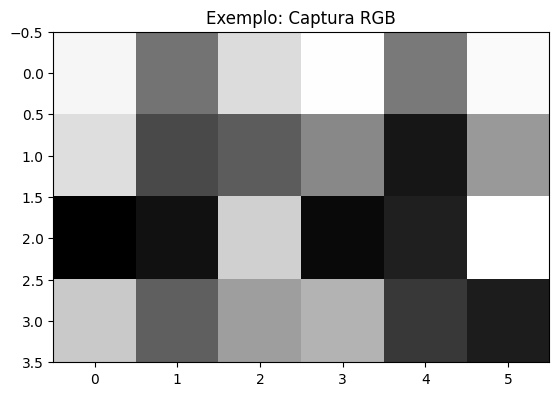

In [ ]:
#| quarto-raw: false
#| label: fig-imagens-sinteticas
#| fig-cap: "Exemplo de imagem sintética gerada por matriz aleatória 4x6."
#| echo: true
#| output: true

# Criando uma imagem preta (zeros) de 5x5 pixels
img_preta = np.zeros((5, 5), dtype='uint8')

# Criando uma imagem branca (255) de 5x5 pixels
img_branca = np.ones((5, 5), dtype='uint8') * 255

# Criando uma imagem aleatória para testes (Ruído)
img_random = mm.randomImage(4, 6, maxValue=255)

print("Matriz Aleatória Gerada:")
print(mm.drawImage(img_random))

mm.show(img_random, title="Exemplo: Captura RGB")

## Lendo e Exibindo Imagens

Em Python, as imagens são lidas como *arrays* do NumPy. Isso significa que toda a potência da álgebra linear está disponível para o processamento de imagens.

A operação mais básica em PDI é a leitura de uma imagem.
A função `mm.read()` da `morph.py` aceita caminhos locais e URLs, ver o resultado na @fig-1-lena.


Dimensões (H, W, Canais): (512, 512, 3)
Tipo de dado: uint8


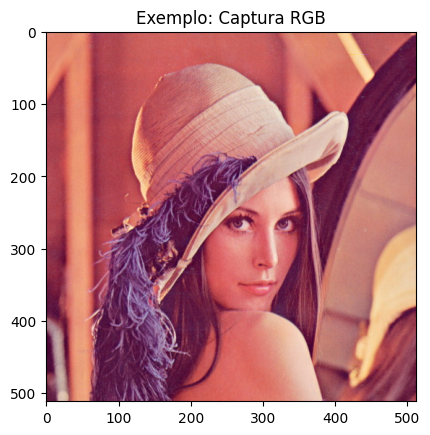

In [ ]:
#| quarto-raw: false
#| label: fig-1-lena
#| fig-cap: "Imagem clássica de processamento de imagens: 'Lena'."
#| echo: true
#| output: true

# Carregando uma imagem de exemplo via URL
url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
img = mm.read(url)

# Exibindo informações básicas
print(f"Dimensões (H, W, Canais): {img.shape}")
print(f"Tipo de dado: {img.dtype}")

# Exibição estética
mm.show(img, title="Exemplo: Captura RGB")

## Conversão de Tipos e Limiarização

Conforme vimos, uma imagem colorida no espaço RGB é representada pela função:

$$
f: \mathbb{E} \to \{0,1,\dots,255\}^3
$$

Ou seja, para cada pixel $(x,y)$, temos três valores $(R,G,B)$ que definem sua cor.

### Conversão para Tons de Cinza {.unnumbered}

Para converter uma imagem RGB em tons de cinza (*grayscale*), é necessário combinar os três canais em um único valor de intensidade $g$, que representa o brilho percebido. Como o olho humano não é igualmente sensível ao vermelho, verde e azul, utiliza-se uma **média ponderada**. O padrão [ITU-R BT.601](https://www.itu.int/rec/R-REC-BT.601/) [@itu_bt601] define os seguintes pesos:

$$
g = 0.299\,R + 0.587\,G + 0.114\,B 
$$ {#eq-1-cinza}

Após o cálculo, o valor $g$ é arredondado para o inteiro mais próximo e ajustado ao intervalo $[0, 255]$. O resultado é uma nova imagem, agora em tons de cinza, representada por:

$$
f_{\text{cinza}}: \mathbb{E} \to \{0,1,\dots,255\}
$$

### Limiarização (*Thresholding*) {.unnumbered}

A partir da imagem em tons de cinza $f_{\text{cinza}}(x,y)$, uma operação fundamental é a **limiarização**, que produz uma imagem **binária** (apenas preto e branco). Para isso, escolhe-se um valor de corte $T$ (geralmente no intervalo $[0,255]$) e define-se:

$$
f_{\text{bin}}(x,y) = 
\begin{cases} 
255 & \text{se } f_{\text{cinza}}(x,y) > T \\[4pt]
0 & \text{caso contrário}
\end{cases}
$$ {#eq-1-limiar}

**Exemplo:** Com $T = 128$, pixels com intensidade acima de 128 tornam-se brancos (255); os demais tornam-se pretos (0).

A limiarização é amplamente usada para **segmentar objetos do fundo**, extrair bordas ou criar máscaras binárias para processamento posterior. 

> **Nota:** O valor 255 representa o branco máximo em imagens de 8 bits, enquanto 0 representa o preto absoluto.

### Exemplo prático de conversão e limiarização {.unnumbered}

A @fig-1-processamento-basico ilustra os principais passos para transformar uma imagem colorida em tons de cinza e, em seguida, binarizá‑la por limiarização.
O código a seguir implementa essas etapas:

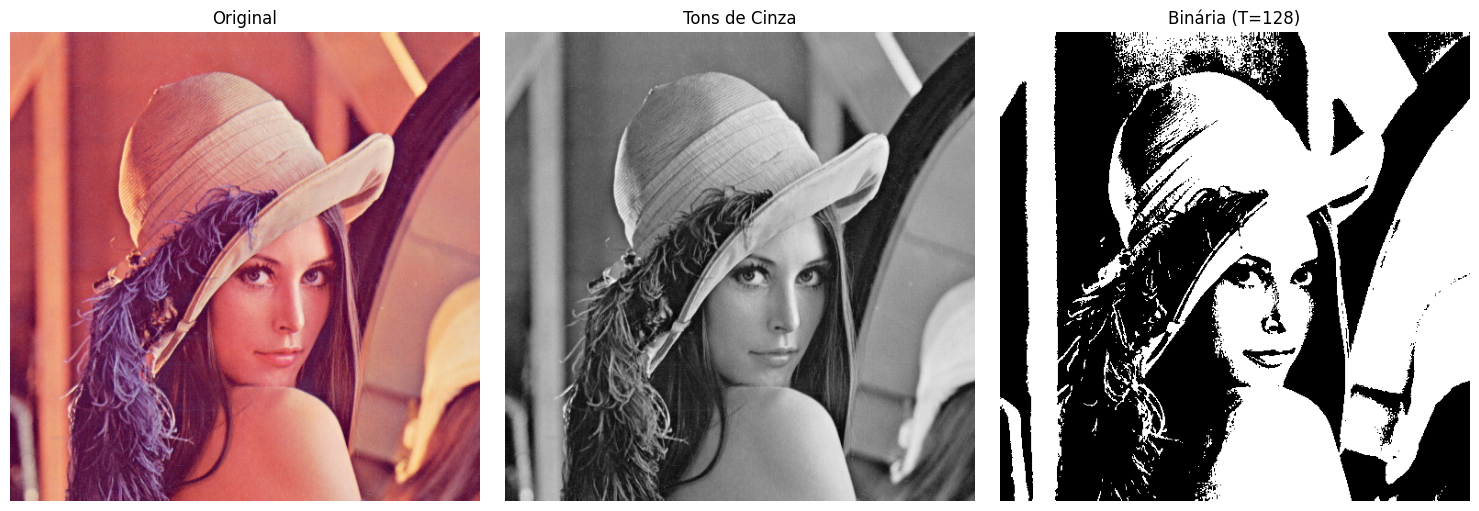

In [ ]:
#| quarto-raw: false
#| label: fig-1-processamento-basico
#| fig-cap: "Processamento básico de imagens: (a) imagem original, (b) imagem em tons de cinza, (c) imagem binarizada por limiar (T=128)."
#| echo: true
#| output: true

import matplotlib.pyplot as plt

# 1. Converter para Tons de Cinza
img_gray = mm.gray(img)

# 2. Aplicar limiar (Pixels > 128 tornam-se 255, outros 0)
limiar = 128
img_binaria = mm.threshold(img_gray, limiar)

# Uso da nova função
mm.show_multiple(
    [img, img_gray, img_binaria], 
    titles=["Original", "Tons de Cinza", f"Binária (T={limiar})"],
    cols=3
)

## Limiarização pelo método de Otsu

Conforme apresentado na @eq-1-limiar, a limiarização converte uma imagem em tons de cinza para binária usando um valor de corte $T$. Até agora fixamos $T = 128$ manualmente.

```python
img_bin_fixo = mm.threshold(img_gray, T=128)
```

Entretanto, a escolha manual de $T$ nem sempre é trivial. A biblioteca `mm` oferece uma alternativa automática: quando o parâmetro `limiar` **não é fornecido**, a função `mm.threshold(img_gray)` calcula o valor de $T$ pelo **método de Otsu** [@otsu1979], que maximiza a variância inter‑classes do histograma, separando automaticamente objeto e fundo.

O código abaixo compara a limiarização manual ($T=128$) com a automática (Otsu), mostrando também o valor de $T$ calculado:

Limiar calculado por Otsu: T = 117.0


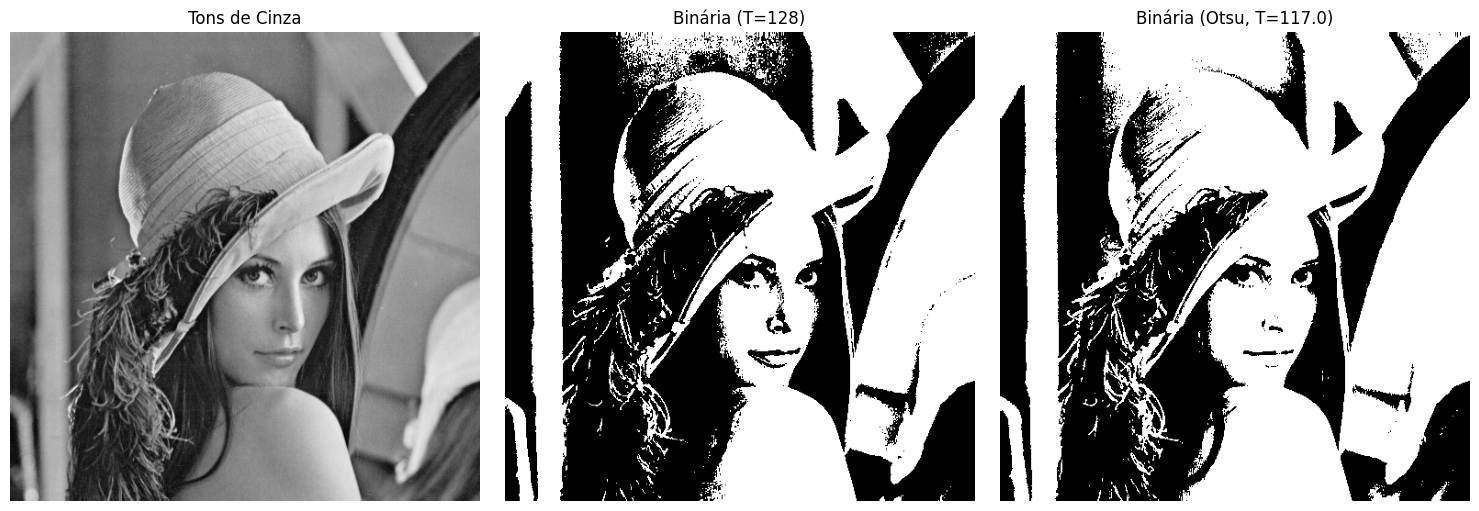

In [ ]:
#| quarto-raw: false
#| label: fig-1-otsu
#| fig-cap: "Comparação entre limiarização manual (T=128) e automática (Otsu) sobre a imagem em tons de cinza."
#| echo: true
#| output: true

# Limiarização com T fixo (manual)
T_fixo = 128
img_bin_fixo = mm.threshold(img_gray, T_fixo)

# Limiarização pelo método de Otsu (T automático)
T_otsu, img_bin_otsu = cv2.threshold(img_gray, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar calculado por Otsu: T = {T_otsu}')
# ou simplesmente:
# img_bin_otsu = mm.threshold(img_gray)

# Exibição lado a lado
mm.show_multiple(
    [img_gray, img_bin_fixo, img_bin_otsu], 
    titles=["Tons de Cinza", f"Binária (T={T_fixo})", f"Binária (Otsu, T={T_otsu})"],
    cols=3
)

A @fig-1-otsu mostra que o limiar obtido por Otsu se adapta automaticamente à imagem, resultando em uma binarização mais eficiente do que um valor fixo, especialmente quando as intensidades do objeto e do fundo são bem separadas no histograma. Essa técnica é amplamente utilizada em sistemas de visão computacional para binarização de documentos, detecção de objetos e pré‑processamento de imagens.

::: {.callout-tip}
### Simplicidade da biblioteca `morph.py` {.unnumbered}

Enquanto o OpenCV exige a chamada completa:

```python
T_otsu, img_bin = cv2.threshold(img_gray, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

a biblioteca `mm` abstrai toda essa complexidade: basta chamar `mm.threshold(img_gray)`. O limiar de Otsu é calculado automaticamente e a imagem binária é retornada diretamente. Essa abordagem permite que você se concentre no conceito, não nos detalhes de implementação.
:::

## Acesso a Pixels

Em Python com NumPy, uma imagem é representada como um **array multidimensional**. Para acessar um pixel específico, utilizam-se as coordenadas **linha** (eixo Y) e **coluna** (eixo X): `img[linha, coluna]`.  

O código abaixo demonstra como obter o valor de um pixel em uma imagem RGB e em sua versão em tons de cinza, além de criar uma pequena imagem sintética para visualizar a estrutura de uma matriz de pixels.

Pixel na posição (100,100):
  - Tons de cinza : 108
  - RGB           : R=182, G=74, B=87

Matriz da imagem sintética 5×5:
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0 255   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


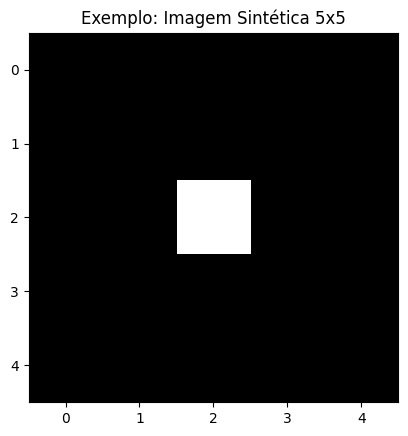

In [ ]:
#| quarto-raw: false
#| label: fig-1-pixel-acesso
#| fig-cap: "Exemplo de acesso a pixels: (a) imagem original com pixel destacado, (b) imagem em tons de cinza, (c) matriz sintética 5×5 com pixel central branco."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt

# Coordenadas do pixel que queremos examinar
r, c = 100, 100

# Acessa o pixel na imagem em tons de cinza (um valor escalar)
pixel_cinza = img_gray[r, c]

# Acessa o pixel na imagem colorida RGB (vetor de 3 valores)
pixel_rgb = img[r, c]

print(f'Pixel na posição ({r},{c}):')
print(f'  - Tons de cinza : {pixel_cinza}')
print(f'  - RGB           : R={pixel_rgb[0]}, G={pixel_rgb[1]}, B={pixel_rgb[2]}')

# Cria uma imagem sintética 5×5 com todos os pixels pretos (0)
syn = np.zeros((5, 5), dtype=np.uint8)
# Torna o pixel central (linha 2, coluna 2) branco (255)
syn[2, 2] = 255

print("\nMatriz da imagem sintética 5×5:")
print(syn)

# Exibe a imagem sintética
# plt.figure(figsize=(3, 3))
# plt.imshow(syn, cmap='gray', vmin=0, vmax=255)
# plt.title("Imagem sintética 5×5\n(pixel central branco)")
# plt.axis('off')
# plt.tight_layout()
# plt.show()
# ou simplesmente:

mm.show(syn, title="Exemplo: Imagem Sintética 5x5")



**Explicação linha a linha:**

1. `img_gray[r, c]` – retorna um único número inteiro entre 0 e 255, correspondente ao nível de cinza naquela posição.  
2. `img[r, c]` – retorna uma tupla ou array com três valores (R, G, B).  
3. `np.zeros((5,5), dtype=np.uint8)` – cria uma matriz $5\times 5$ preenchida com zeros (preto).  
4. `syn[2, 2] = 255` – altera o elemento central da matriz para 255 (branco), demonstrando como modificar um pixel.  
5. A exibição com `plt.imshow` revela um pequeno quadrado com um ponto branco no meio, ilustrando visualmente a estrutura discreta da imagem.

A @fig-1-pixel-acesso mostra os valores impressos e a imagem sintética. Perceba que a indexação em Python é **zero‑based**: o canto superior esquerdo é `(0,0)`. A ordem **linha × coluna** corresponde à estrutura matricial da imagem: primeira dimensão → altura (Y), segunda dimensão → largura (X).

## Resumo

Neste capítulo foram apresentados os fundamentos de representação de imagens digitais:

- **Imagem digital** = função $f(x,y)$ que mapeia coordenadas para intensidades (escalares ou vetoriais).
- **Domínio**: conjunto finito $\mathbb{E} = \{(x,y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H\}$.
- **Tipos principais**: binária ($\mathcal{V} = \{0, 255\}$), tons de cinza ($\mathcal{V} = [0,255]$) e RGB ($\mathcal{V} = [0,255]^3$).
- A biblioteca `morph.py` (ou `mm`) oferece funções didáticas para operações básicas de PDI, como `mm.gray()`, `mm.threshold()`, `mm.show_multiple()`.
- **Armadilha NumPy**: nunca use `[[0]*n]*m` para criar matrizes — use sempre `np.zeros()` ou `np.ones()`.
- **Limiarização** converte tons de cinza em binária; o **método de Otsu** determina o valor de corte automaticamente maximizando a variância inter-classes.
- Acesso a pixels via `img[linha, coluna]`, com indexação **zero-based**.

O Capítulo 2 abordará **histogramas e equalização de contraste**.


## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta segunda edição, além dos notebooks interativos no Google Colab, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelos autores como base de conhecimento, garantindo respostas alinhadas ao conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

::: {.callout-important appearance="default" icon=false}
### 🎓 Estude com o Tutor Inteligente {.unnumbered}

Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 01](https://notebooklm.google.com/notebook/aca1138a-02aa-4f98-b777-1e25795ca635)
:::

### Funcionalidades Disponíveis na Plataforma {.unnumbered}

O **NotebookLM** oferece uma suíte avançada de ferramentas baseadas em IA para transformar o conteúdo estático do livro em uma experiência de aprendizado dinâmica e multimídia. Conforme ilustrado na @fig-notebooklm, a plataforma utiliza técnicas de **RAG** (*Retrieval-Augmented Generation*), fundamentadas no trabalho de @lewis2020retrieval, para basear as respostas estritamente nos documentos fornecidos e minimizar a ocorrência de alucinações.

As principais funcionalidades incluem:

* **Resumos Multimodais (Áudio e Vídeo)**: Geração de conversas naturais entre especialistas no formato de **Resumo em Áudio** (estilo podcast) e **Resumo em Vídeo**, discutindo os temas centrais do capítulo, como as diferenças entre processamento de imagens e visão computacional, ou a interpretação de transformações como a limiarização e o método de Otsu.
* **Visualização de Estruturas (Mapa Mental e Infográfico)**: Criação automática de diagramas que conectam visualmente os conceitos, por exemplo, o fluxo de processamento desde a captura da imagem digital, passando pela conversão para tons de cinza, limiarização e segmentação binária.
* **Ferramentas de Avaliação (Teste e Cartões Didáticos)**: Geração de **Testes** de múltipla escolha e **Cartões Didáticos** (*flashcards*) para fixação de conhecimento, baseados no texto autoral (ex.: perguntas sobre a fórmula de conversão RGB→cinza ou sobre o funcionamento do limiar global e de Otsu).
* **Apoio à Apresentação (Slides e Relatórios)**: Auxílio na estruturação de **Apresentações de Slides** e na redação de **Relatórios** técnicos e **Briefings**, facilitando a comunicação de resultados de experimentos com imagens.
* **Análise de Dados (Tabela de Dados)**: Organização de dados extraídos do texto em tabelas estruturadas, auxiliando na compreensão de exemplos práticos, como a comparação entre diferentes valores de limiar ou a análise de histogramas de níveis de cinza.
* **Chat Contextualizado**: Permite o questionamento direto sobre o código e a teoria, como: *"Como implementar a conversão de RGB para tons de cinza usando os pesos do padrão ITU‑R BT.601?"* ou *"O que acontece com a imagem binária se eu escolher um limiar T=200 em vez de T=128?"*.

::: {#fig-notebooklm .lightbox fig-alt="Estúdio do NotebookLM." fig-align="center" width=80%}

![](imagens/fig1_notebooklm.png){width=80% fig-align="center"}

Estúdio do NotebookLM.

:::

## Lista de Exercícios

1. (15%) Com suas próprias palavras, defina **imagem digital** e **pixel**. Dê um exemplo concreto de como uma imagem colorida (RGB) é representada matricialmente no computador.

2. (15%) Explique as diferenças entre **imagem binária**, **tons de cinza (8 bits)** e **colorida RGB**, indicando a faixa de valores possíveis para cada pixel em cada tipo.

3. (20%) Considerando a fórmula de conversão RGB → tons de cinza do padrão ITU‑R BT.601:
   $$g = 0.299\,R + 0.587\,G + 0.114\,B$$
   Calcule o valor do pixel em tons de cinza para $(R,G,B) = (80, 180, 30)$. Arredonde para o inteiro mais próximo.

4. (20%) O que é **limiarização** (*thresholding*)? Explique a diferença entre escolher um limiar $T$ fixo (ex.: $T=128$) e utilizar o **método de Otsu** para determinação automática do limiar. Em poucas palavras, como o método de Otsu escolhe o limiar?

5. (15%) No contexto da biblioteca didática `mm` discutida no capítulo, responda:
   - a) (7,5%) Como se acessa o valor do pixel na posição (linha=50, coluna=60) de uma imagem em tons de cinza `img_gray`?
   - b) (7,5%) Qual a vantagem de usar `mm.threshold(img_gray)` sem passar o limiar? Compare com a chamada equivalente no OpenCV.

6. (15%) O que a propriedade `img.shape` retorna para uma imagem NumPy no formato RGB? Dê um exemplo concreto com uma imagem de 640×480 pixels.

---

**PS1** – Como pode ser observado, algumas questões exigem apenas a aplicação direta de conceitos, enquanto outras requerem reflexão e exemplos próprios. Seu trabalho será avaliado considerando a **coerência da argumentação**, a **correção dos cálculos** e a **clareza dos exemplos**. Procure ser conciso, mas evite linguagem telegráfica: você precisa demonstrar seu entendimento de forma completa.

**PS2** – O ditado "uma figura fala mais do que mil palavras" é particularmente verdadeiro em processamento de imagens. Se julgar útil, acompanhe suas respostas com pequenos desenhos, diagramas ou ilustrações (ex.: representação de uma matriz de pixels, efeito da limiarização em uma imagem simples, etc.).

## Referências do Capítulo

Este capítulo baseou‑se principalmente nas seguintes obras de processamento de imagens e visão computacional:

- @gonzalez2018digital para fundamentos de **Processamento Digital de Imagens** (PDI).
- @russ2023 para aspectos práticos de **processamento e análise de imagens** (The Image Processing Handbook, 7ª ed., 2016).
- @szeliski2022 para **visão computacional** e algoritmos fundamentais (Computer Vision: Algorithms and Applications, 2ª ed., 2022).
- @bradski2016 para a biblioteca **OpenCV** e exemplos práticos em Python (Learning OpenCV 4, 2ª ed., 2016).
- @lewis2020retrieval para o conceito de **geração aumentada por recuperação (RAG)**, aplicado ao NotebookLM.